# SPARC PRD: fusdb vs cfspopcon full-grid comparison

This notebook is the human-readable companion to `test_sparc_prd.py`. It runs
fusdb's `Reactor.popcon` scan over the **same 40×30 `(n_e, T_e)` grid** cfspopcon
scanned in `input.yaml`, then compares every field against cfspopcon's reference
`output/dataset.nc` cell-by-cell over the certified operating region.

The fixture (`reactor.yaml`) is driven from input.yaml's inputs — geometry,
field, current, and the impurity concentrations (He 6e-2, O 3.1e-3, W 1.5e-5
of `n_e`), which drive the line radiation, the **derived** `Z_eff` (~1.34,
within ~1% of the reference, via the Mavrin 2018 T-dependent mean charges) and
the scalar ion-inventory anchor `n_i_avg` (the f-fractions keep the species
split: helium as `f_He4`, O+W folded into the generic Z=6 impurity by
quasineutrality charge). Profiles carry **both** Angioni density-peaking
offsets (electron −0.1 and ion −0.2), plus the Martin+Ryter L-H scaling and
cfspopcon's stored-energy and ITER98y2 conventions.

**fusdb still works as fusdb.** Nothing about the solver was bent to match: the
match comes from *selecting* the relations that encode cfspopcon's modelling
choices (`Poloidal beta (cfspopcon)`, `Plasma stored energy (cfspopcon)`,
`Energy confinement time ITER98y2 (cfspopcon)`, `L-H transition threshold power
(Martin-Ryter)`, `Hydrogenic bremsstrahlung (cfspopcon)`, `Impurity line
radiation (radas coronal)`) instead of fusdb's more general defaults, and
supplying the same composition. Radiation follows cfspopcon's convention
`P_rad = P_brem(Z_eff=1) + P_sync + P_line`: the impurity cooling curves
already include each impurity's own continuum, so the Z_eff-scaled
bremsstrahlung would double-count it. `P_line` runs on the radas (OpenADAS)
coronal Lz tables — the reference's own radiation method (the Mavrin-2018
polynomial fits stay the fusdb default elsewhere). The pointwise `n_i ∝ n_e`
profile tie is a *weak default* in fusdb: here the ion profile decouples
through its own Angioni peaking and parabolic generator, with quasineutrality
anchored at the averages level — the same structure cfspopcon has, where the
fuel peaks less than the electrons and the impurity fraction varies radially.
Where a convention is *not* importable (cfspopcon's dilution-free pressure)
the field stays a documented `gap`.

The table below reports the **median relative error** over the certified cells for
every mappable field, grouped by category, **including the fields fusdb does not
compute on the scan** (`missing`) so the gaps stay explicit. See the `FIELDS`
table and `reactor.yaml` comments for the physics behind each category.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# _compare.py lives next to this notebook.
sys.path.insert(0, str(Path.cwd()))
import _compare as C

result = C.run_scan(outputs=C.SCAN_OUTPUTS)
handle = C.load_dataset()
comparisons = C.compare(result, handle)

success = result["popcon"]["success"]
print(f"certified {int(success.sum())} / {success.size} grid points")

/home/alessmor/Scrivania/fusdb/src/fusdb/relations/edge/scrape_off_layer/two_point_model.py:156: RuntimeWarning: divide by zero encountered in scalar divide
  return (1.0 - SOL_momentum_loss_fraction) ** 3 / (1.0 - SOL_power_loss_fraction) ** 2
/home/alessmor/Scrivania/fusdb/src/fusdb/relations/edge/scrape_off_layer/two_point_model.py:170: RuntimeWarning: divide by zero encountered in scalar divide
  return (1.0 - SOL_momentum_loss_fraction) ** 2 / (1.0 - SOL_power_loss_fraction)
/home/alessmor/Scrivania/fusdb/src/fusdb/relation.py:329: RuntimeWarning: invalid value encountered in scalar subtract
  diff = lhs - rhs


certified 1029 / 1200 grid points


## Field-by-field agreement

`match` — fusdb reproduces cfspopcon within ~10% grid-wide (asserted by the test).
`fusion` — fusion chain, ~6% median (fuel profile on its own ion peaking).
`gap` — a known modelling difference (carried as `xfail`).
`missing` — fusdb does not compute this on the scan (shown so it can be closed).

With the decoupled ion profile the scan is essentially exact where the physics
is shared: `P_in` ~0.0%, `tau_E` ~0.0%, both density peakings ~0.4%, `P_aux`
~2%, `P_fus` ~6% (PRD cell +0.8%) — and **`Q` itself lands at ~9% median on
cfspopcon's own definition**, so it is asserted as a `match`. The radiation
chain is closed: with the radas 2-D `Lz(T_e, n_e)` tables evaluated pointwise
on the real He/O/W mix (the reference's own method, same bicubic log-log
spline), **`P_radiation` dropped from ~53% (no line radiation) through ~14%
(Mavrin fits) to ~3% median** — now a `match` — which pulled `P_sep` to ~0.3%
and `P_SOL/P_LH` to ~8.5%. The remaining max (~160%) is confined to the
lowest-density grid column (`n_e = 1e19`) where `P_radiation` is ~0.1 MW and
synchrotron-dominated: the ~0.06 MW absolute difference inflates the relative
error there. The He3 side-channels (D-He3, T-He3, He3-He3) are pruned — with
no He3 in the plasma their rate variables would otherwise be unconstrained
free cores producing spurious fusion power.

In [2]:
_cat_order = {"match": 0, "fusion": 1, "gap": 2, "missing": 3}
rows = []
for c in comparisons:
    rows.append({
        "category": c.category,
        "cfspopcon field": c.dataset_name,
        "fusdb variable": c.fusdb_name,
        "cells": c.n_cells,
        "median %": np.nan if not c.computed else round(c.median_rel * 100, 1),
        "max %": np.nan if not c.computed else round(c.max_rel * 100, 1),
        "within 10%": np.nan if not c.computed else round(c.frac_within_10 * 100, 0),
    })
df = pd.DataFrame(rows)
df = df.sort_values(
    by=["category", "median %"],
    key=lambda s: s.map(_cat_order) if s.name == "category" else s,
    na_position="last",
).reset_index(drop=True)


def _highlight(row):
    color = {"match": "#e6ffe6", "fusion": "#fffbe6", "gap": "#ffefe6", "missing": "#f0f0f0"}[row["category"]]
    return [f"background-color: {color}"] * len(row)


df.style.apply(_highlight, axis=1).format({"median %": "{:.1f}", "max %": "{:.1f}", "within 10%": "{:.0f}"}, na_rep="—")

,category,cfspopcon field,fusdb variable,cells,median %,max %,within 10%
0,match,average_ion_temp,T_i_avg,1029,0.0,0.0,100
1,match,dilution,dilution,1029,0.0,0.0,100
2,match,greenwald_fraction,f_GW,1029,0.0,0.0,100
3,match,peak_electron_temp,T0,1029,0.0,0.0,100
4,match,peak_ion_temp,T_i_peak,1029,0.0,0.0,100
5,match,P_in,P_in,1029,0.0,0.2,100
6,match,energy_confinement_time,tau_E,1029,0.0,0.1,100
7,match,plasma_stored_energy,W_th,1029,0.0,0.0,100
8,match,spitzer_resistivity,spitzer_resistivity,1029,0.0,0.0,100
9,match,rho_star,rho_star,1029,0.0,0.0,100


### Summary by category

In [3]:
computed = df[df["cells"] > 0]
summary = computed.groupby("category").agg(
    n_fields=("cfspopcon field", "count"),
    median_of_medians=("median %", "median"),
)
n_missing = int((df["cells"] == 0).sum())
print(summary)
print(f"\nfields fusdb does not compute on the scan (missing): {n_missing}")

          n_fields  median_of_medians
category                             
fusion           4               5.65
gap              7              12.60
match           50               0.35

fields fusdb does not compute on the scan (missing): 3


## Operating-space contour overlay

`P_fus`, `Q`, `P_aux`, `P_SOL/P_LH` and `t_flattop` on the `(n_e, T_e)` plane:
**fusdb solid, cfspopcon dashed**, one colour per quantity.

Reading the overlay (the mismatches worth understanding):

* **Grey shaded region — fusdb does not certify it.** Run in `h_mode` across the
  whole grid (faithful to cfspopcon's single ITER98y2 scaling), fusdb certifies
  `T_e ≳ 9` keV: below that the H-mode power/confinement balance needs negative
  auxiliary power, so those cells fail. cfspopcon reports them anyway, so its
  dashed contours continue into the shading while the fusdb solid lines stop at
  its edge — that boundary (not a bug) is why the solid lines look 'interrupted'
  around `T_e ≈ 9`. (The next section fills this region with per-point regimes.)

* **`Q` is compared as `Q_cfspopcon`** — cfspopcon's own definition, `Q =
  P_fus / (P_aux_launched + P_ohmic)` (its dataset `P_external` equals
  `P_aux_launched + P_ohmic` exactly). fusdb's `Q_sci = P_fus / P_aux` drops the
  ohmic term, so it diverges to infinity where `P_aux → 0` while cfspopcon's Q
  stays finite — comparing on one definition removes that artificial blow-up.
  On this definition `Q` now agrees to ~9% median; the max still blows up at
  the handful of near-ignition cells where `P_aux → 0` amplifies any residual
  stored-energy difference (`P_loss ~ W_th^3.2`).

* **`t_flattop` shows only the cfspopcon (dashed) contour** because fusdb does
  not compute it on the scan (the SOL/flux chain gap) — a deliberate mismatch.

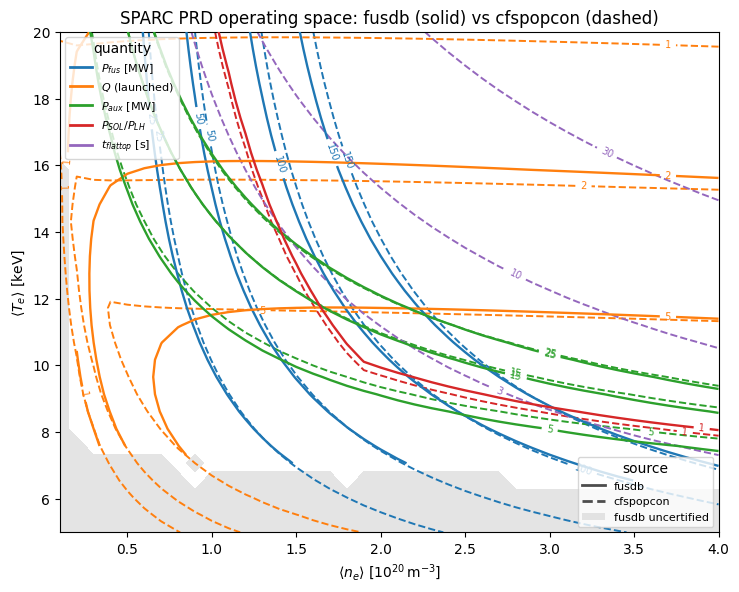

In [4]:
import matplotlib.pyplot as plt

ax = C.contour_overlay(result, handle)
plt.show()

## Native automatic per-point regime

`Reactor.popcon` now selects the confinement regime **per grid point
automatically** — there is no fixed-regime option. For each cell it runs the
machine's escalation chain (`h_mode`/`l_mode`/`ohmic_mode`, or
`i_mode`/`l_mode`/`ohmic_mode`) and assigns the strongest regime whose
sustainment guard holds on that regime's own solve: H-mode where
`P_sep >= P_LH`, ohmic where `P_sep <= P_OL_thresh`, with L-mode as the
accessible fallback for the intermediate / L-H-bistable band. The result
carries a `regime_index` map (the background colour below), and the whole
operating space is covered. `run_scan_multiregime` is now just
`reactor.popcon(...)`.

**Caveat (unchanged):** L-mode cells use the L-mode `tau_E` scaling, not
cfspopcon's H-mode ITER98y2, so their values diverge from `dataset.nc` there by
construction — the fusdb solid contours **kink at the H/L boundary**. The
faithful value comparison (the table above) is therefore taken against a
forced-`h_mode` scan, matching cfspopcon's single-scaling choice.

/home/alessmor/Scrivania/fusdb/src/fusdb/relations/edge/scrape_off_layer/two_point_model.py:156: RuntimeWarning: divide by zero encountered in scalar divide
  return (1.0 - SOL_momentum_loss_fraction) ** 3 / (1.0 - SOL_power_loss_fraction) ** 2


/home/alessmor/Scrivania/fusdb/src/fusdb/relations/edge/scrape_off_layer/two_point_model.py:170: RuntimeWarning: divide by zero encountered in scalar divide
  return (1.0 - SOL_momentum_loss_fraction) ** 2 / (1.0 - SOL_power_loss_fraction)


/home/alessmor/Scrivania/fusdb/src/fusdb/relation.py:329: RuntimeWarning: invalid value encountered in scalar subtract
  diff = lhs - rhs


/home/alessmor/Scrivania/fusdb/src/fusdb/relations/edge/scrape_off_layer/two_point_model.py:156: RuntimeWarning: divide by zero encountered in scalar divide
  return (1.0 - SOL_momentum_loss_fraction) ** 3 / (1.0 - SOL_power_loss_fraction) ** 2


/home/alessmor/Scrivania/fusdb/src/fusdb/relations/edge/scrape_off_layer/two_point_model.py:170: RuntimeWarning: divide by zero encountered in scalar divide
  return (1.0 - SOL_momentum_loss_fraction) ** 2 / (1.0 - SOL_power_loss_fraction)


/home/alessmor/Scrivania/fusdb/src/fusdb/relations/edge/scrape_off_layer/two_point_model.py:156: RuntimeWarning: divide by zero encountered in scalar divide
  return (1.0 - SOL_momentum_loss_fraction) ** 3 / (1.0 - SOL_power_loss_fraction) ** 2


/home/alessmor/Scrivania/fusdb/src/fusdb/relation.py:329: RuntimeWarning: invalid value encountered in scalar subtract
  diff = lhs - rhs


/home/alessmor/Scrivania/fusdb/src/fusdb/relations/edge/scrape_off_layer/two_point_model.py:170: RuntimeWarning: divide by zero encountered in scalar divide
  return (1.0 - SOL_momentum_loss_fraction) ** 2 / (1.0 - SOL_power_loss_fraction)


/home/alessmor/Scrivania/fusdb/src/fusdb/relation.py:329: RuntimeWarning: invalid value encountered in scalar subtract
  diff = lhs - rhs


h_mode     : 579 cells
l_mode     : 450 cells
ohmic_mode : 0 cells
no regime  : 171 cells   (certified 1029/1200)


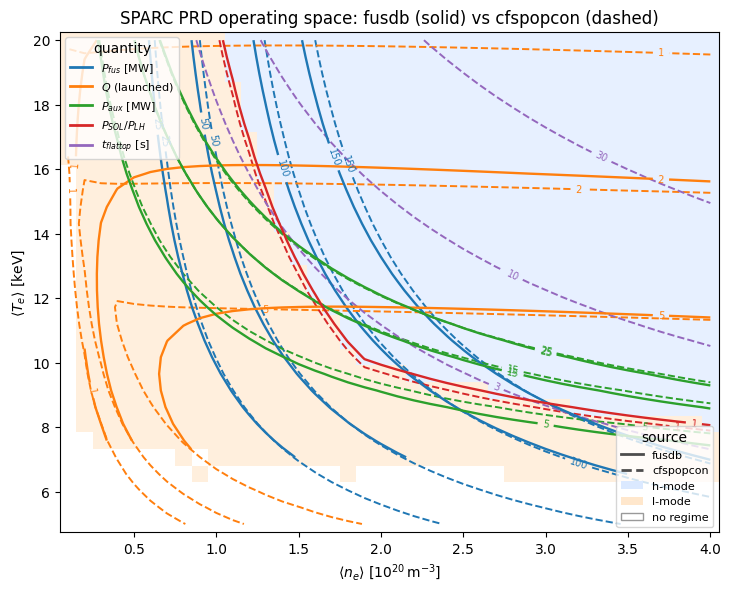

In [5]:
multi = C.run_scan_multiregime(outputs=C.SCAN_OUTPUTS)
ri = multi["popcon"]["regime_index"]
for i, name in enumerate(multi["popcon"]["regime_names"]):
    print(f"{name:11s}: {int((ri == i).sum())} cells")
print(f"no regime  : {int((ri < 0).sum())} cells   (certified {int(multi['popcon']['success'].sum())}/1200)")

ax = C.contour_overlay(multi, handle)
plt.show()

In [6]:
handle.close()